# Environment Setup & Dependencies

In [ ]:
!pip install -q ultralytics==8.3.1

!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8n.pt

!pip install -q roboflow

from roboflow import Roboflow
rf = Roboflow(api_key= "Your Roboflow API KEY")
project = rf.workspace("YOUR WORKSPACE-NAME").project("YOUR PROJECT-NAME")
version = project.version(2)
dataset = version.download("yolov8")


# Dataset Setup


In [ ]:
import cv2
import yaml
import shutil
from pathlib import Path

SOURCE_DATASET = Path("/content/Brain-tumor-2")
CLAHE_DATASET = Path("/content/Brain-tumor-2-clahe")


clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for split in ["train", "valid", "test"]:
    source_images = SOURCE_DATASET / split / "images"
    source_labels = SOURCE_DATASET / split / "labels"

    output_images = CLAHE_DATASET / split / "images"
    output_labels = CLAHE_DATASET / split / "labels"

    output_images.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)

    for image_path in source_images.iterdir():
        if image_path.suffix.lower() not in image_extensions:
            continue


        image = cv2.imread(str(image_path))


        lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab_image)

        enhanced_l = clahe.apply(l_channel)

        enhanced_lab = cv2.merge((enhanced_l, a_channel, b_channel))
        enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)


        cv2.imwrite(
            str(output_images / image_path.name),
            enhanced_image
        )


        label_path = source_labels / f"{image_path.stem}.txt"
        if label_path.exists():
            shutil.copy2(label_path, output_labels / label_path.name)

with open(SOURCE_DATASET / "data.yaml", "r") as file:
    data_config = yaml.safe_load(file)

data_config["path"] = str(CLAHE_DATASET)
data_config["train"] = "train/images"
data_config["val"] = "valid/images"

if (CLAHE_DATASET / "test" / "images").exists():
    data_config["test"] = "test/images"

with open(CLAHE_DATASET / "data.yaml", "w") as file:
    yaml.safe_dump(data_config, file, sort_keys=False)

print("CLAHE dataset created at:", CLAHE_DATASET)
print("New YAML file:", CLAHE_DATASET / "data.yaml")

CLAHE dataset created at: /content/Brain-tumor-2-clahe
New YAML file: /content/Brain-tumor-2-clahe/data.yaml


# YOLOV8 Model Training

In [ ]:
!yolo task=detect mode=train epochs=25 batch=64 plots=True \
model=yolov8n.pt \
data=/content/Brain-tumor-2-clahe/data.yaml


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.1 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Brain-tumor-2-clahe/data.yaml, epochs=25, time=None, patience=100, batch=64, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False,

# Model loading

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4






Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-ein

In [ ]:
from ultralytics import YOLO
print("✅ YOLOv8 imported successfully")


✅ YOLOv8 imported successfully


# Tumor Detection / Inference

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")
results = model.predict(
    source="/content/Brain-tumor-2/valid/images",
    conf=0.25,
    save=True
)




image 1/624 /content/Brain-tumor-2/valid/images/Tr-gl_0014_jpg.rf.d87a2db6bcbe323db4b2f36e561cfd92.jpg: 640x640 1 glioma, 9.6ms
image 2/624 /content/Brain-tumor-2/valid/images/Tr-gl_0016_jpg.rf.f745fa061866e655c9dcefef916d7687.jpg: 640x640 1 glioma, 7.0ms
image 3/624 /content/Brain-tumor-2/valid/images/Tr-gl_0019_jpg.rf.d0ecc24027b6efdf49ce0cf452dcaf3a.jpg: 640x640 2 gliomas, 6.9ms
image 4/624 /content/Brain-tumor-2/valid/images/Tr-gl_0039_jpg.rf.f8921edb100f3e0f534c41f71db29c60.jpg: 640x640 1 glioma, 6.9ms
image 5/624 /content/Brain-tumor-2/valid/images/Tr-gl_0051_jpg.rf.92f43444e02e62c2efe1d6e3a3d181b5.jpg: 640x640 1 glioma, 6.9ms
image 6/624 /content/Brain-tumor-2/valid/images/Tr-gl_0052_jpg.rf.357c421cd61da6514954853b5e24cdb8.jpg: 640x640 1 glioma, 6.9ms
image 7/624 /content/Brain-tumor-2/valid/images/Tr-gl_0057_jpg.rf.6b12f795de067520da4ab15b76456e4f.jpg: 640x640 1 glioma, 6.9ms
image 8/624 /content/Brain-tumor-2/valid/images/Tr-gl_0059_jpg.rf.82003425a7bd1b5da74916237c16a636.jpg

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model.predict(source="/content/Brain-tumor-2/valid/images", conf=0.25, save=True)



image 1/624 /content/Brain-tumor-2/valid/images/Tr-gl_0014_jpg.rf.d87a2db6bcbe323db4b2f36e561cfd92.jpg: 640x640 1 glioma, 7.2ms
image 2/624 /content/Brain-tumor-2/valid/images/Tr-gl_0016_jpg.rf.f745fa061866e655c9dcefef916d7687.jpg: 640x640 1 glioma, 6.9ms
image 3/624 /content/Brain-tumor-2/valid/images/Tr-gl_0019_jpg.rf.d0ecc24027b6efdf49ce0cf452dcaf3a.jpg: 640x640 2 gliomas, 6.9ms
image 4/624 /content/Brain-tumor-2/valid/images/Tr-gl_0039_jpg.rf.f8921edb100f3e0f534c41f71db29c60.jpg: 640x640 1 glioma, 6.9ms
image 5/624 /content/Brain-tumor-2/valid/images/Tr-gl_0051_jpg.rf.92f43444e02e62c2efe1d6e3a3d181b5.jpg: 640x640 1 glioma, 6.9ms
image 6/624 /content/Brain-tumor-2/valid/images/Tr-gl_0052_jpg.rf.357c421cd61da6514954853b5e24cdb8.jpg: 640x640 1 glioma, 6.9ms
image 7/624 /content/Brain-tumor-2/valid/images/Tr-gl_0057_jpg.rf.6b12f795de067520da4ab15b76456e4f.jpg: 640x640 1 glioma, 6.9ms
image 8/624 /content/Brain-tumor-2/valid/images/Tr-gl_0059_jpg.rf.82003425a7bd1b5da74916237c16a636.jpg

# Prediction Visualization

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
images = glob.glob("/content/runs/detect/predict3/*.jpg")

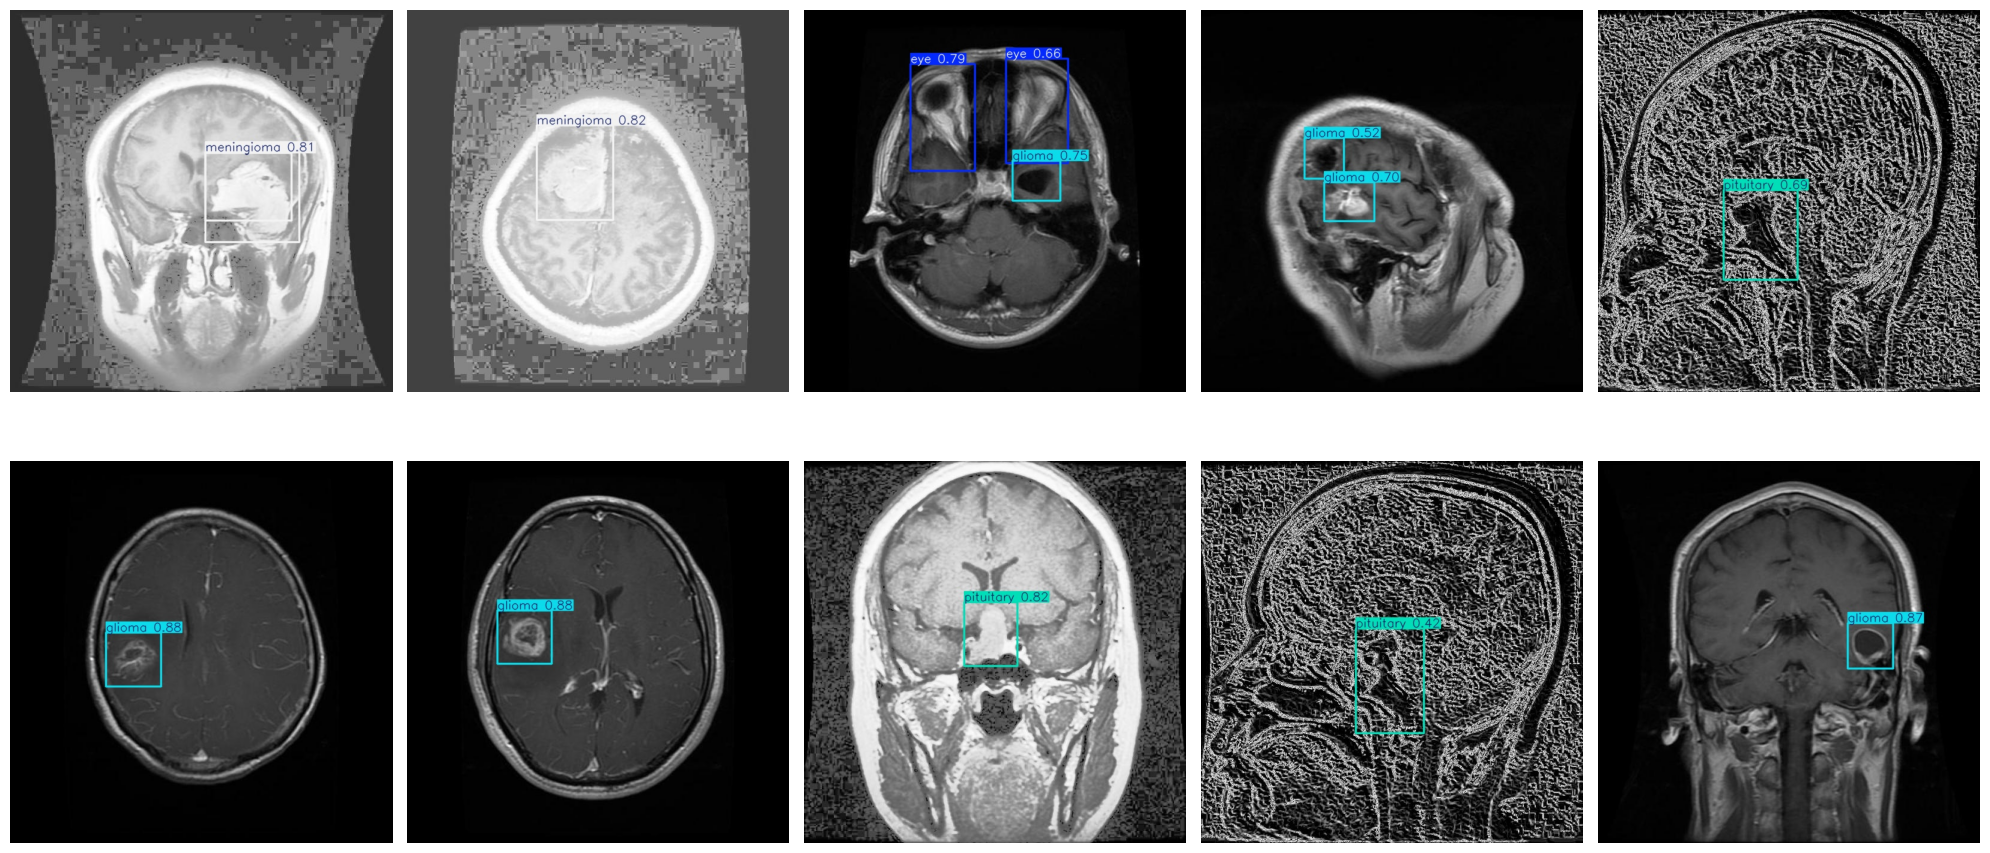

In [ ]:
images_to_display = images[:10]
fig, axes =plt.subplots(2,5, figsize =(20,10))

for i , ax in enumerate(axes.flat):
  if i < len(images_to_display):
    img = mpimg.imread(images_to_display[i])
    ax.imshow(img)
    ax.axis('off')
  else:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
yolo_model = YOLO("/content/runs/detect/train/weights/best.pt")


# Single Image Detection


image 1/1 /content/Brain-tumor-2/valid/images/m1-118-_jpg.rf.5b35bb6eed60b9d86b19fa19a67b980a.jpg: 640x640 2 eyes, 1 meningioma, 16.1ms
Speed: 3.5ms preprocess, 16.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


array([[[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]],

       [[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]],

       [[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]],

       ...,

       [[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]],

       [[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]],

       [[9, 9, 9],
        [9, 9, 9],
        [9, 9, 9],
        ...,
        [9, 9, 9],
        [9, 9, 9],
        [9, 9, 9]]], dtype=uint8)
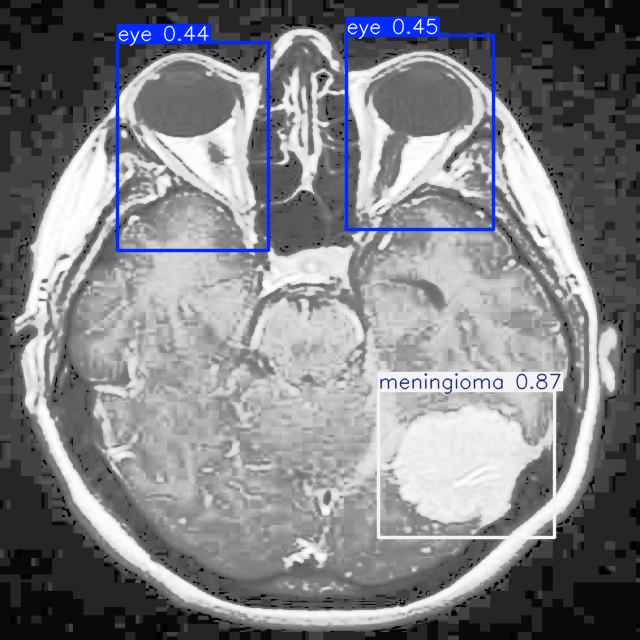

In [ ]:
result =model.predict(source = '/content/Brain-tumor-2/valid/images/m1-118-_jpg.rf.5b35bb6eed60b9d86b19fa19a67b980a.jpg',imgsz = 640, conf = 0.25)
annotated_img =result[0].plot()
annotated_img[:, :, ::-1]


In [ ]:
!ls /content/Brain-tumor-2/valid/images | head -10

m-101-_jpg.rf.99f553e7769ce8e08e87513d4430b89d.jpg
m-107-_jpg.rf.b1aa94e824ecdc95dadfbdeaf702286d.jpg
m-107-_jpg.rf.c9d18e28368269b4729a491aa3890457.jpg
m1-102-_jpg.rf.ea55058c819e4571a26d9607a1e09a94.jpg
m-110-_jpg.rf.604cda6733627862ccc98ae88d5ed375.jpg
m1-118-_jpg.rf.5b35bb6eed60b9d86b19fa19a67b980a.jpg
m1-126-_jpg.rf.4bad9df8520e22f74f85594e8ec6b8db.jpg
m1-12-_jpg.rf.96d203732831210bc28dad31996b8603.jpg
m1-131-_jpg.rf.90cb8a9d9241c3b658178893aa059f8a.jpg
m1-140-_jpg.rf.5f933dc9cec69193f93fedc04fb83e06.jpg


# Training Results Analysis

In [ ]:
import pandas as pd

# Load the results CSV file
results_df = pd.read_csv('/content/runs/detect/train/results.csv')

# Display the results
print(results_df.head())
print(results_df.tail())

                  epoch        train/box_loss        train/cls_loss  \
0                     1                1.6679                4.1162   
1                     2                1.5539                2.7266   
2                     3                1.5570                2.3241   
3                     4                1.5512                1.9698   
4                     5                1.4955                1.6937   

         train/dfl_loss  metrics/precision(B)     metrics/recall(B)  \
0                1.5878               0.00768               0.67399   
1                1.4195               0.00424               0.57936   
2                1.4246               0.77014               0.02636   
3                1.4269               0.59427               0.47863   
4                1.3932               0.53180               0.45499   

       metrics/mAP50(B)   metrics/mAP50-95(B)          val/box_loss  \
0               0.12871               0.06434                1.3558   
1   

# Model Performance Evaluation

In [ ]:
max_precision = results_df['metrics/precision(B)'].max()
max_recall = results_df['metrics/recall(B)'].max()
max_map50 = results_df['metrics/mAP50(B)'].max()

# Calculate F1-score
if (max_precision + max_recall) > 0:
    f1_score = 2 * (max_precision * max_recall) / (max_precision + max_recall)
else:
    f1_score = 0.0

print(f"Maximum Precision: {max_precision:.4f}")
print(f"Maximum Recall: {max_recall:.4f}")
print(f"Maximum mAP50 (mean Average Precision at 50% IoU): {max_map50:.4f}")
print(f"Calculated F1-score: {f1_score:.4f}")

# Model Deployment

In [ ]:
!pip install gradio

import gradio as gr
import cv2
import numpy as np

def predict(image):
  result =model.predict(source =image,imgsz = 640, conf = 0.25)
  annotated_image =result[0].plot()
  annotated_image[:, :, ::-1]
  return annotated_image

app = gr.Interface(
    fn = predict,
    inputs = gr.Image(type = "numpy", label ="Upload an Image"),
    outputs = gr.Image(type = "numpy", label ="Detect a Brain Tumor"),
    title = "Brain Tumor Detection Using YOLO V8 made for SIP",
    description = "Upload an Image ant eh YOLO V8 model will detect and Annotate the Brain Tumor"
)
app.launch()

from google.colab import drive
drive.mount('/content/drive')

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8057b2e8a71e092651.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Mounted at /content/drive
